# eBay Shill Bidding Dataset — EDA & 피처 중요도 분석

**목적** — 숏폼 C2C 실시간 경매 서비스의 *AI 이상거래(허위입찰) 탐지 모델* 초기 학습 데이터로 이 데이터셋이 쓸 만한지 검증하고, 어떤 피처가 실제로 신호를 만드는지 밝힌다.

## 분석 질문
1. 데이터의 **단위**는 무엇인가? (행 1개 = 무엇 1건인가) → 우리 Risk Score 산정 단위와 맞는가
2. 어떤 피처가 `Class`를 설명하는가? 중요도 순위는?
3. 우리 서비스 정책상 **재현 불가능한 피처**가 있는가? 있다면 그것을 뺐을 때 성능은 어떻게 변하는가
4. 그 빈자리를 메우려면 우리 DB 로그로 어떤 피처를 새로 만들어야 하는가

## 서비스 정책 연결점 (§6. AI 이상거래 탐지 정책)
- Risk Score 산정 단위 = **경매별 × 입찰자 단위**
- **Successive Outbidding 은 서비스 정책상 발생하지 않음** (§5 입찰 정책: "최고 입찰자인 동안 추가 입찰 불가") → 제외 또는 대체 피처 적용 후 재학습
- 자동 제재 없음, 관리자 검토 큐 정렬용으로만 사용
- 신규 사용자는 Risk Score 미산출 / 최소 분석 조건 미충족 시 탐지 제외

> 결론과 적용안은 맨 마지막 §13 · §14 셀에 정리되어 있다.

---
## §0. 환경 준비

In [2]:
# !pip install pandas numpy matplotlib seaborn scikit-learn scipy

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

warnings.filterwarnings('ignore')

pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 50)

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.unicode_minus'] = False

# 한글 폰트 (설치된 것 중 첫 번째로)
_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'NanumBarunGothic']:
    if _f in _avail:
        plt.rcParams['font.family'] = _f
        break

sns.set_palette('deep')
RANDOM_STATE = 42
print('font:', plt.rcParams['font.family'])

font: ['Malgun Gothic']


---
## §1. 데이터 로드와 기본 구조

In [3]:
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
CSV_PATH = ROOT / 'data' / 'Shill Bidding Dataset.csv'

df = pd.read_csv(CSV_PATH)
print('shape:', df.shape)
df.head(10)

shape: (6321, 13)


,Record_ID,Auction_ID,Bidder_ID,Bidder_Tendency,Bidding_Ratio,Successive_Outbidding,Last_Bidding,Auction_Bids,Starting_Price_Average,Early_Bidding,Winning_Ratio,Auction_Duration,Class
0,1,732,_***i,0.200000,0.400000,0.0,0.000028,0.000000,0.993593,0.000028,0.666667,5,0
1,2,732,g***r,0.024390,0.200000,0.0,0.013123,0.000000,0.993593,0.013123,0.944444,5,0
2,3,732,t***p,0.142857,0.200000,0.0,0.003042,0.000000,0.993593,0.003042,1.000000,5,0
3,4,732,7***n,0.100000,0.200000,0.0,0.097477,0.000000,0.993593,0.097477,1.000000,5,0
4,5,900,z***z,0.051282,0.222222,0.0,0.001318,0.000000,0.000000,0.001242,0.500000,7,0
5,8,900,i***e,0.038462,0.111111,0.0,0.016844,0.000000,0.000000,0.016844,0.800000,7,0
6,10,900,m***p,0.400000,0.222222,0.0,0.006781,0.000000,0.000000,0.006774,0.750000,7,0
7,12,900,k***a,0.137931,0.444444,1.0,0.768044,0.000000,0.000000,0.016311,1.000000,7,1
8,13,2370,g***r,0.121951,0.185185,1.0,0.035021,0.333333,0.993528,0.023963,0.944444,7,1
9,27,600,e***t,0.155172,0.346154,0.5,0.570994,0.307692,0.993593,0.413788,0.611111,7,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6321 entries, 0 to 6320
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Record_ID               6321 non-null   int64  
 1   Auction_ID              6321 non-null   int64  
 2   Bidder_ID               6321 non-null   str    
 3   Bidder_Tendency         6321 non-null   float64
 4   Bidding_Ratio           6321 non-null   float64
 5   Successive_Outbidding   6321 non-null   float64
 6   Last_Bidding            6321 non-null   float64
 7   Auction_Bids            6321 non-null   float64
 8   Starting_Price_Average  6321 non-null   float64
 9   Early_Bidding           6321 non-null   float64
 10  Winning_Ratio           6321 non-null   float64
 11  Auction_Duration        6321 non-null   int64  
 12  Class                   6321 non-null   int64  
dtypes: float64(8), int64(4), str(1)
memory usage: 642.1 KB


In [29]:
# 데이터 무결성 점검
print('결측치 총합                        :', int(df.isna().sum().sum()))
print('완전 중복 행                       :', int(df.duplicated().sum()))
print('Record_ID 유니크                   :', df['Record_ID'].nunique(), '/', len(df))
print('(Auction_ID, Bidder_ID) 조합 유니크 :',
      df.groupby(['Auction_ID', 'Bidder_ID']).ngroups, '/', len(df))

결측치 총합                        : 0
완전 중복 행                       : 0
Record_ID 유니크                   : 6321 / 6321
(Auction_ID, Bidder_ID) 조합 유니크 : 6321 / 6321


### 컬럼 사전

| 컬럼 | 단위 | 의미 | 우리 서비스 재현 가능성 |
|---|---|---|---|
| `Record_ID` | - | 행 식별자 | - |
| `Auction_ID` | 경매 | 경매 식별자 (그룹 키) | `auction_id` |
| `Bidder_ID` | 입찰자 | 입찰자 식별자 (마스킹됨) | `user_id` |
| `Bidder_Tendency` | 입찰자 | **특정 판매자 상품에만 몰리는 성향** (판매자 집중도) | O 계산 가능 |
| `Bidding_Ratio` | 경매×입찰자 | 해당 경매의 전체 입찰 중 이 사람이 차지한 비율 | O 계산 가능 |
| `Successive_Outbidding` | 경매×입찰자 | **자기 자신을 연속으로 추월한 정도** (값은 0 / 0.5 / 1) | **X — 정책상 항상 0** |
| `Last_Bidding` | 경매×입찰자 | 경매 기간으로 정규화한 마지막 입찰 시점 | △ 연장 정책 때문에 재정의 필요 |
| `Auction_Bids` | 경매 | 경매의 총 입찰 수 (정규화) | O 계산 가능 |
| `Starting_Price_Average` | 경매 | 시장 평균 대비 시작가 수준 | △ 카테고리 기준가 필요 |
| `Early_Bidding` | 경매×입찰자 | 경매 기간으로 정규화한 첫 입찰 시점 | O 계산 가능 |
| `Winning_Ratio` | 입찰자 | 참여 경매 대비 승리(최고가 확보) 비율 | △ 정의가 모호함 — §6 소견 참고 |
| `Auction_Duration` | 경매 | 경매 기간 (일) | △ 우린 1시간~5일 → 시간 단위 재정의 |
| `Class` | - | **타깃**: 1 = 허위입찰(shill) 의심 | 관리자 확정 라벨로 대체 |

In [6]:
TARGET = 'Class'
ID_COLS = ['Record_ID', 'Auction_ID', 'Bidder_ID']
FEATURES = [c for c in df.columns if c not in ID_COLS + [TARGET]]

# 단위별 분류 — 같은 경매의 행끼리 값이 공유되는 피처를 구분해 둔다 (그룹 분할이 필요한 이유)
AUCTION_LEVEL = ['Auction_Bids', 'Starting_Price_Average', 'Auction_Duration']
BIDDER_LEVEL = [f for f in FEATURES if f not in AUCTION_LEVEL]

y = df[TARGET]

print('피처 수         :', len(FEATURES))
print('경매 단위 피처   :', AUCTION_LEVEL)
print('입찰자 단위 피처 :', BIDDER_LEVEL)

피처 수         : 9
경매 단위 피처   : ['Auction_Bids', 'Starting_Price_Average', 'Auction_Duration']
입찰자 단위 피처 : ['Bidder_Tendency', 'Bidding_Ratio', 'Successive_Outbidding', 'Last_Bidding', 'Early_Bidding', 'Winning_Ratio']


---
## §2. 타깃 분포와 불균형

,count,pct
0 (정상),5646,89.32
1 (허위입찰 의심),675,10.68


불균형 비율 = 1 : 8.36


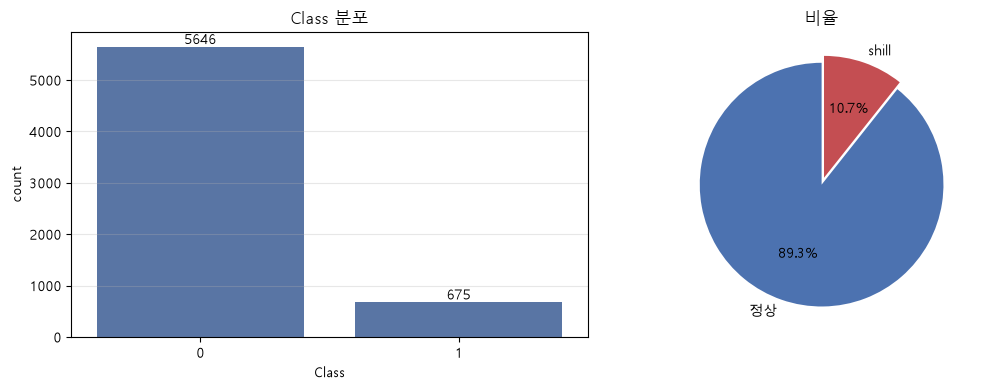

In [7]:
vc = y.value_counts().sort_index()
ratio = y.value_counts(normalize=True).sort_index()
summary = pd.DataFrame({'count': vc, 'pct': (ratio * 100).round(2)})
summary.index = ['0 (정상)', '1 (허위입찰 의심)']
display(summary)
print(f'불균형 비율 = 1 : {vc[0] / vc[1]:.2f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=y, ax=ax[0])
ax[0].set_title('Class 분포')
ax[0].bar_label(ax[0].containers[0])
ax[1].pie(vc, labels=['정상', 'shill'], autopct='%1.1f%%', startangle=90,
          colors=['#4C72B0', '#C44E52'], explode=(0, 0.06))
ax[1].set_title('비율')
plt.tight_layout()
plt.show()

> **소견** — 양성이 약 10.7% 로 불균형이다 (1 : 8.4). 극단적인 수준은 아니라서 `class_weight='balanced'` 정도면 충분하고 SMOTE 같은 오버샘플링은 불필요하다.
>
> 다만 **정확도(accuracy)는 지표로 쓰면 안 된다** — 전부 정상이라고 찍어도 89.3% 가 나온다.
> 이하 모든 평가는 **PR-AUC / Precision@Recall** 을 주 지표로 사용한다.

---
## §3. 식별자 분석 — 데이터 단위와 누수 위험

이 데이터는 평범한 i.i.d. 테이블이 아니다. 같은 `Auction_ID` 의 행들은 `Auction_Bids`, `Starting_Price_Average`, `Auction_Duration` 값을 **공유**한다.
무작위로 train/test 를 나누면 같은 경매가 양쪽에 걸쳐 성능이 낙관적으로 부풀려진다. → **`GroupShuffleSplit(groups=Auction_ID)` 필수**(Auction_ID 기준으로 train/test를 나눠야 한다)

경매 수           : 807
입찰자 수         : 1054
경매당 평균 입찰자 : 7.83 명


,경매당 입찰자 수
count,807.000000
mean,7.832714
std,4.385915
min,1.000000
25%,5.000000
50%,7.000000
75%,10.000000
max,26.000000


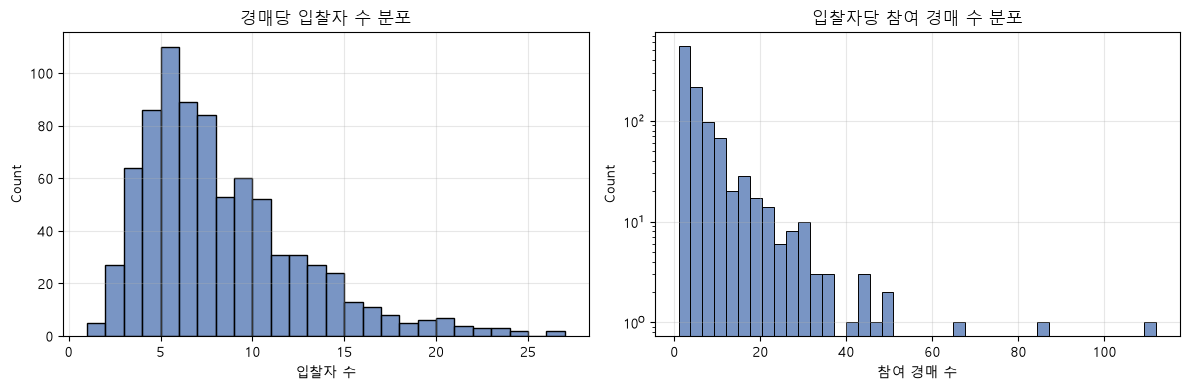

In [8]:
n_auction = df['Auction_ID'].nunique()
n_bidder = df['Bidder_ID'].nunique()
print(f'경매 수           : {n_auction}')
print(f'입찰자 수         : {n_bidder}')
print(f'경매당 평균 입찰자 : {len(df) / n_auction:.2f} 명')

per_auction = df.groupby('Auction_ID').size()
display(per_auction.describe().to_frame('경매당 입찰자 수'))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(per_auction, bins=range(1, per_auction.max() + 2), ax=ax[0])
ax[0].set_title('경매당 입찰자 수 분포')
ax[0].set_xlabel('입찰자 수')
sns.histplot(df.groupby('Bidder_ID').size(), bins=40, ax=ax[1])
ax[1].set_title('입찰자당 참여 경매 수 분포')
ax[1].set_xlabel('참여 경매 수')
ax[1].set_yscale('log')
plt.tight_layout()
plt.show()

In [9]:
# 경매 단위: shill 이 1명 이상 끼어있는 경매 비율
auc_has_shill = df.groupby('Auction_ID')[TARGET].max()
print(f'shill 포함 경매 : {int(auc_has_shill.sum())} / {n_auction} '
      f'({auc_has_shill.mean() * 100:.1f}%)')

# 입찰자 단위: 항상 shill / 항상 정상 / 경매마다 다름
bg = df.groupby('Bidder_ID')[TARGET].agg(['sum', 'size'])
never = int((bg['sum'] == 0).sum())
always = int((bg['sum'] == bg['size']).sum())
mixed = n_bidder - never - always
print(f'항상 정상 입찰자  : {never}')
print(f'항상 shill 입찰자 : {always}')
print(f'경매마다 다름     : {mixed}  ← 전체 입찰자의 {mixed / n_bidder * 100:.1f}%')

shill 포함 경매 : 478 / 807 (59.2%)
항상 정상 입찰자  : 668
항상 shill 입찰자 : 27
경매마다 다름     : 359  ← 전체 입찰자의 34.1%


> **소견 (설계에 직결)** — 807개 경매, 1054명 입찰자, 경매당 평균 7.8명. 경매의 **59.2%** 에 shill 의심 입찰자가 섞여 있다.
>
> 결정적인 점: **입찰자 359명(34%)이 경매마다 판정이 다르다.** 즉 shill 은 *사람의 속성*이 아니라 *특정 경매에서의 행동*이다.
>
> → 정책의 `Risk Score 산정 단위 = 경매별 × 입찰자` 가 데이터적으로 올바른 선택이고, 사용자 단위 단일 점수로는 잡을 수 없다.
> 정책의 "사용자 위험도 누적 관리"는 별도 집계로 가져가되, **탐지 자체는 반드시 경매 단위**로 돌려야 한다.

---
## §4. 기술통계와 분포

In [10]:
desc = df[FEATURES].describe().T
desc['zero_pct'] = (df[FEATURES] == 0).mean() * 100
desc['nunique'] = df[FEATURES].nunique()
desc['skew'] = df[FEATURES].skew()
display(desc[['min', '25%', '50%', '75%', 'max', 'mean', 'std', 'zero_pct', 'nunique', 'skew']].round(4))

,min,25%,50%,75%,max,mean,std,zero_pct,nunique,skew
Bidder_Tendency,0.0000,0.0270,0.0625,0.1667,1.0000,0.1425,0.1971,2.4205,489,2.5312
Bidding_Ratio,0.0118,0.0435,0.0833,0.1667,1.0000,0.1277,0.1315,0.0000,400,2.4216
Successive_Outbidding,0.0000,0.0000,0.0000,0.0000,1.0000,0.1038,0.2797,86.6635,3,2.5661
Last_Bidding,0.0000,0.0479,0.4409,0.8604,0.9999,0.4631,0.3801,0.1266,5807,0.0877
Auction_Bids,0.0000,0.0000,0.1429,0.4545,0.7882,0.2316,0.2553,44.6607,49,0.5873
Starting_Price_Average,0.0000,0.0000,0.0000,0.9936,0.9999,0.4728,0.4899,51.4634,22,0.0864
Early_Bidding,0.0000,0.0266,0.3601,0.8268,0.9999,0.4307,0.3808,0.2373,5690,0.2204
Winning_Ratio,0.0000,0.0000,0.0000,0.8519,1.0000,0.3677,0.4366,57.5858,72,0.4042
Auction_Duration,1.0000,3.0000,5.0000,7.0000,10.0000,4.6151,2.4666,0.0000,5,-0.1314


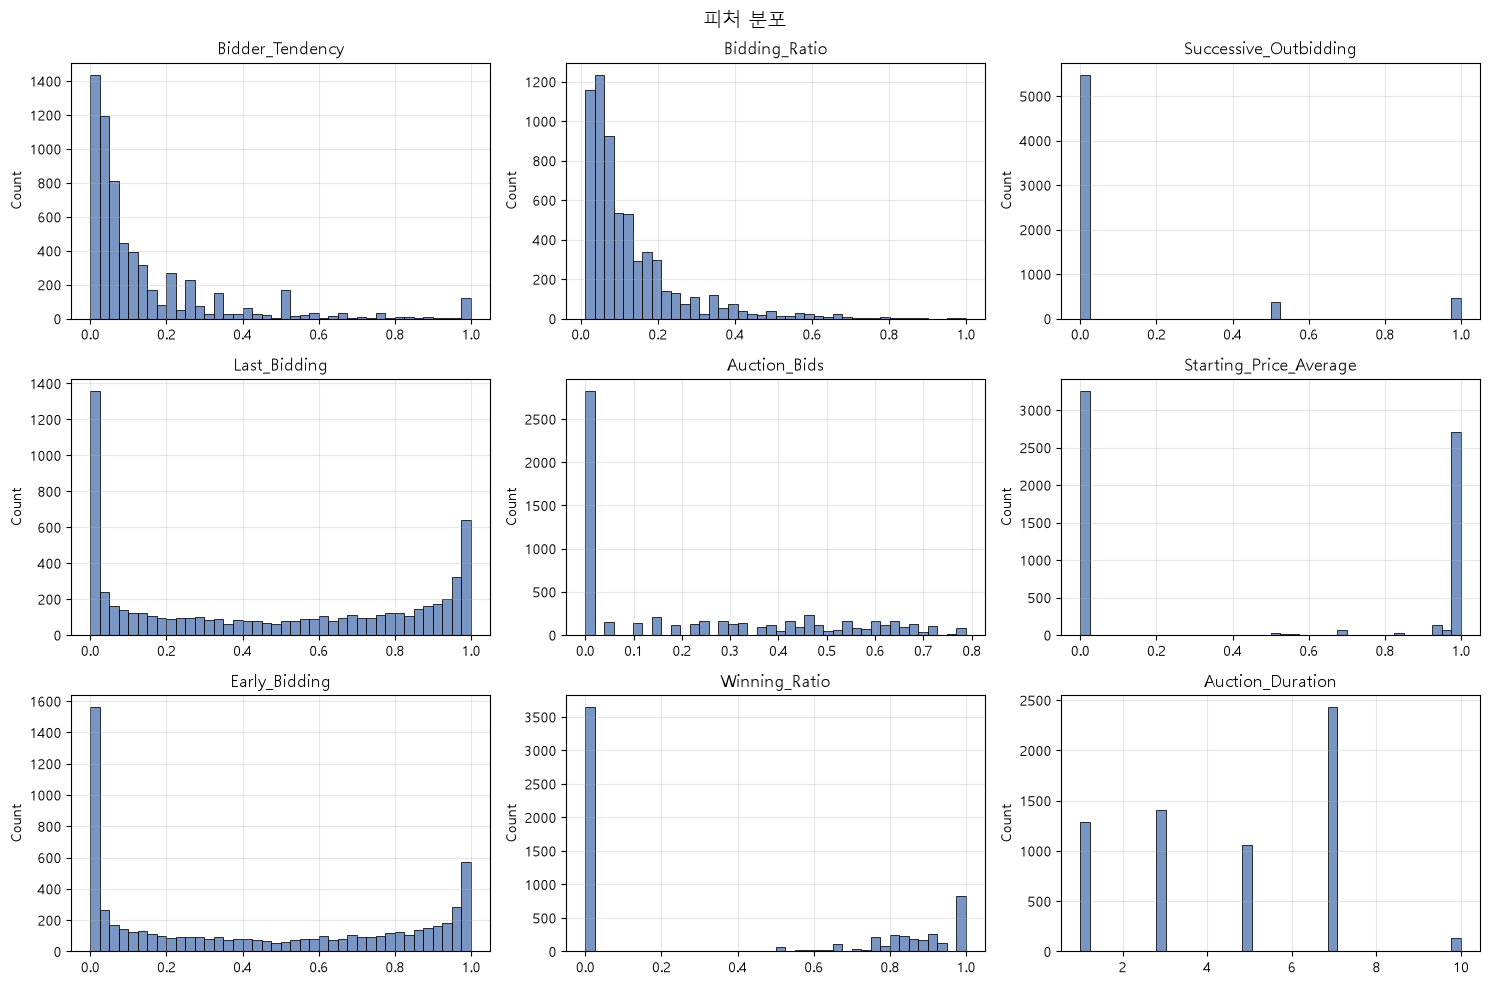

In [11]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, f in zip(axes.ravel(), FEATURES):
    sns.histplot(df[f], bins=40, ax=ax, color='#4C72B0')
    ax.set_title(f)
    ax.set_xlabel('')
fig.suptitle('피처 분포', fontsize=14)
plt.tight_layout()
plt.show()

> **소견** — 분포 모양이 피처마다 전혀 다르다.
>
> - `Successive_Outbidding` 은 **사실상 범주형**이다. 값이 `0 / 0.5 / 1` 세 개뿐이고 86.7% 가 0. 연속형처럼 보이지만 아니다.
> - `Winning_Ratio`(57.6%), `Starting_Price_Average`(51.5%), `Auction_Bids`(44.7%) 는 0 집중이 심하다.
>   → "이력 없음"과 "값이 진짜 0"이 같은 0 으로 인코딩되어 있다. 우리는 **이력 없음을 별도 불리언 플래그로 분리**해야 한다 (콜드스타트 처리의 근거).
> - `Last_Bidding` / `Early_Bidding` 은 고유값 5,700개대의 연속형이고 양 끝이 두툼한 U 형이다.

---
## §5. 클래스별 분포 비교 — 어느 피처가 두 집단을 가르는가

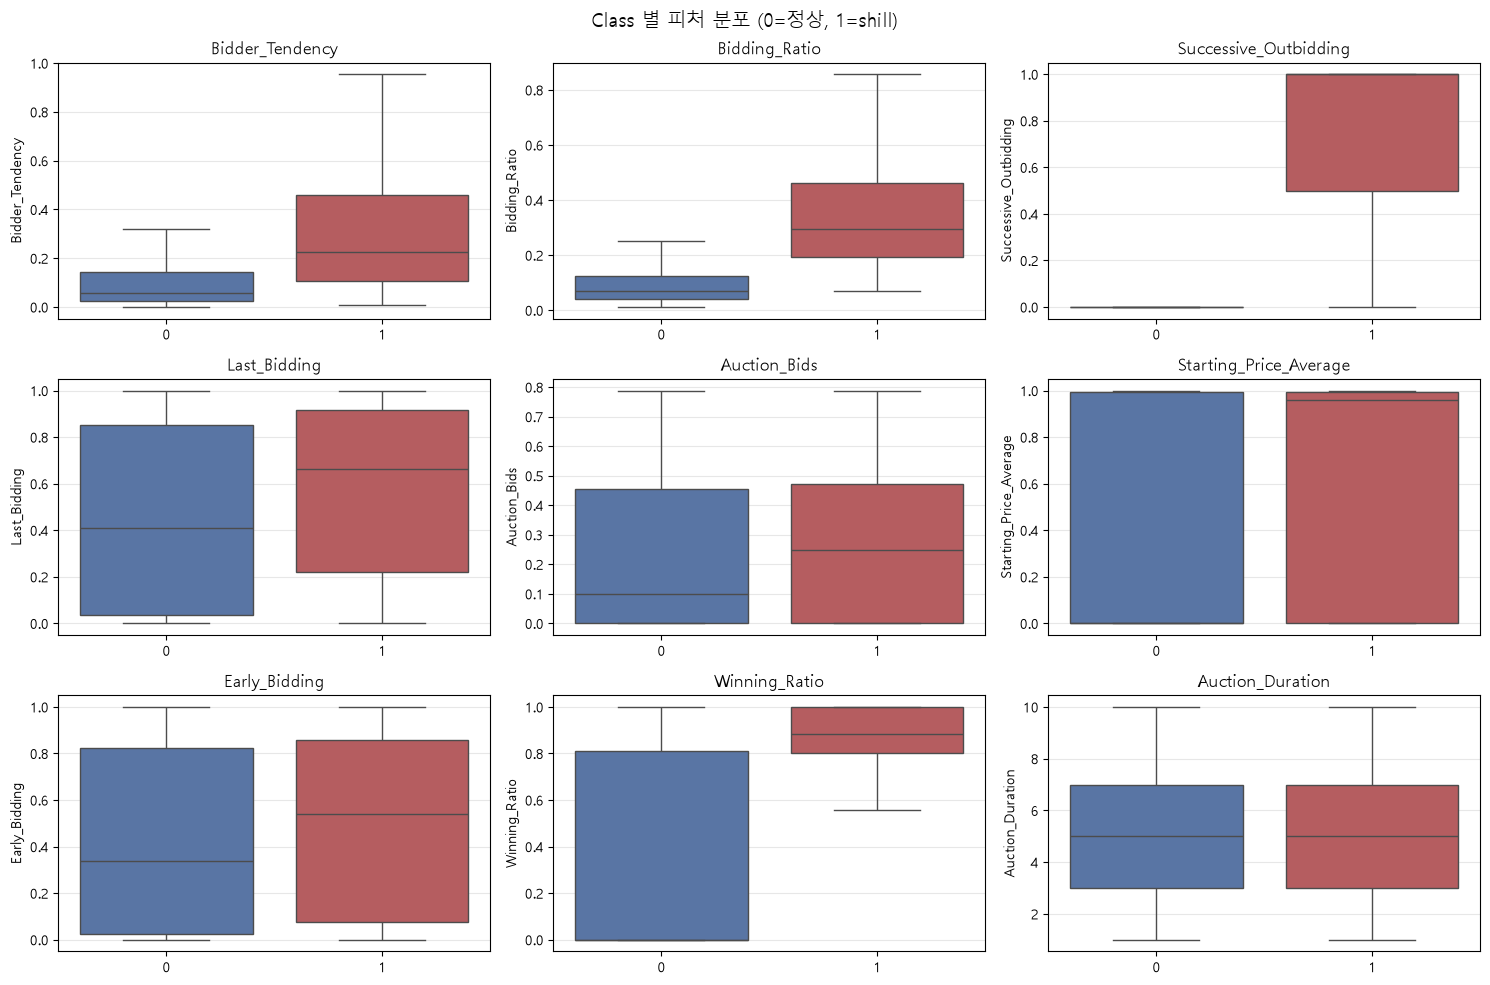

In [12]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
for ax, f in zip(axes.ravel(), FEATURES):
    sns.boxplot(data=df, x=TARGET, y=f, ax=ax, showfliers=False,
                palette=['#4C72B0', '#C44E52'])
    ax.set_title(f)
    ax.set_xlabel('')
fig.suptitle('Class 별 피처 분포 (0=정상, 1=shill)', fontsize=14)
plt.tight_layout()
plt.show()

In [13]:
cls_mean = df.groupby(TARGET)[FEATURES].mean().T
cls_mean.columns = ['mean_정상', 'mean_shill']
cls_mean['배율'] = cls_mean['mean_shill'] / cls_mean['mean_정상'].replace(0, np.nan)
display(cls_mean.sort_values('배율', ascending=False).round(4))

,mean_정상,mean_shill,배율
Successive_Outbidding,0.0166,0.8326,50.0087
Bidding_Ratio,0.1018,0.3443,3.3826
Winning_Ratio,0.3082,0.8653,2.8073
Bidder_Tendency,0.1224,0.3110,2.5406
Last_Bidding,0.4503,0.5705,1.2669
Auction_Bids,0.2276,0.2648,1.1632
Early_Bidding,0.4236,0.4897,1.1559
Starting_Price_Average,0.4656,0.5332,1.1451
Auction_Duration,4.5971,4.7659,1.0367


---
## §6. 단변량 판별력 순위

모델을 돌리기 전에, **피처 하나만으로** 라벨을 얼마나 가르는지 세 가지 지표로 교차 확인한다.

- **AUC** — 랭킹 분리력. 0.5 = 무정보, 1.0 = 완벽 분리 (단조성만 보므로 스케일에 무관)
- **점이연 상관계수 (point-biserial r)** — 선형 관계의 방향과 세기
- **상호정보량 (MI)** — 비선형 관계까지 포함한 의존성

In [14]:
from scipy.stats import pointbiserialr, mannwhitneyu
from sklearn.metrics import roc_auc_score
from sklearn.feature_selection import mutual_info_classif

mi = mutual_info_classif(df[FEATURES], y, random_state=RANDOM_STATE)

rows = []
for i, f in enumerate(FEATURES):
    r, _ = pointbiserialr(df[f], y)
    _, p_u = mannwhitneyu(df.loc[y == 1, f], df.loc[y == 0, f])
    rows.append({
        'feature': f,
        'AUC': roc_auc_score(y, df[f]),
        'point_biserial_r': r,
        'MI(nats)': mi[i],
        'p_value': p_u,
    })

uni = pd.DataFrame(rows).set_index('feature').sort_values('AUC', ascending=False)
display(uni.round(4))

,AUC,point_biserial_r,MI(nats),p_value
feature,,,,
Successive_Outbidding,0.9919,0.9010,0.2825,0.0000
Bidding_Ratio,0.9185,0.5694,0.1732,0.0000
Winning_Ratio,0.8231,0.3941,0.0985,0.0000
Bidder_Tendency,0.7832,0.2955,0.1280,0.0000
Last_Bidding,0.5945,0.0977,0.0122,0.0000
Early_Bidding,0.5510,0.0536,0.0043,0.0000
Auction_Bids,0.5459,0.0450,0.0000,0.0000
Starting_Price_Average,0.5351,0.0426,0.0042,0.0011
Auction_Duration,0.5255,0.0211,0.0000,0.0236


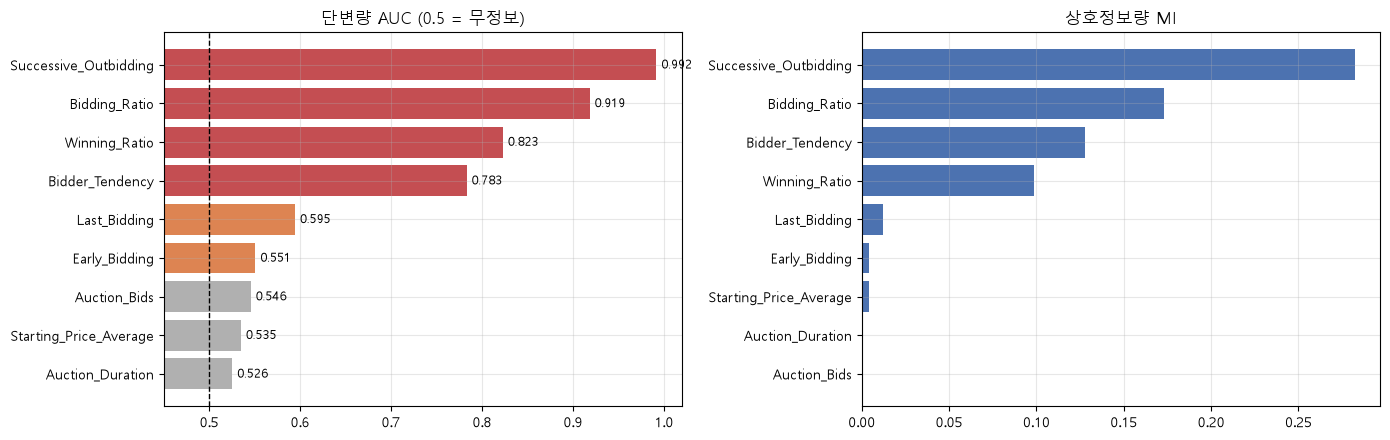

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))

o = uni.sort_values('AUC')
colors = ['#C44E52' if v > 0.7 else ('#DD8452' if v > 0.55 else '#B0B0B0') for v in o['AUC']]
ax[0].barh(o.index, o['AUC'], color=colors)
ax[0].axvline(0.5, ls='--', c='k', lw=1)
ax[0].set_xlim(0.45, 1.02)
ax[0].set_title('단변량 AUC (0.5 = 무정보)')
for i, v in enumerate(o['AUC']):
    ax[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

o2 = uni.sort_values('MI(nats)')
ax[1].barh(o2.index, o2['MI(nats)'], color='#4C72B0')
ax[1].set_title('상호정보량 MI')
plt.tight_layout()
plt.show()

> **소견 1 — 피처는 세 계층으로 갈린다**
>
> | 계층 | 피처 | AUC | 해석 |
> |---|---|---|---|
> | **지배적** | `Successive_Outbidding` | 0.992 | 사실상 라벨 그 자체 (§8 에서 정밀 분석) |
> | **유효** | `Bidding_Ratio` | 0.919 | 한 경매에서 입찰을 독식하는 행동 |
> | | `Winning_Ratio` | 0.823 | 낙찰 회피 성향 |
> | | `Bidder_Tendency` | 0.783 | 특정 판매자에게 몰리는 정도 |
> | **거의 무의미** | `Last_Bidding` 0.595 · `Early_Bidding` 0.551 · `Auction_Bids` 0.546 · `Starting_Price_Average` 0.535 · `Auction_Duration` 0.526 | ≈ 0.5 | 단독으로는 신호 없음 |
>
> MI 도 정확히 같은 순서를 가리킨다 (0.285 / 0.134 / 0.096 / 0.052 → 나머지 5개는 모두 < 0.01).
> 즉 **실질적으로 쓸모있는 피처는 4개뿐**이고, 그중 1개는 우리가 쓸 수 없다.

> **소견 2 — `Winning_Ratio` 는 "낙찰률"이 아니라 "낙찰 회피율"이다**
>
> 원 데이터셋의 정의는 `Winning_Ratio = 1 - (낙찰 횟수 / 적극 참여 경매 수)` 이다.
> 앞에 `1 -` 이 붙어 있으므로 **값이 높을수록 낙찰을 하지 않은 것**이다.
> 따라서 정상 0.308 vs shill **0.865** 는 "shill 은 참여는 많이 하지만 낙찰은 피한다"는 설명과 정확히 일치한다. 모순이 아니다.
> (적극 참여 = 해당 경매에서 `Bidding_Ratio > 0.1` 인 경매로 정의된다.)
>
> **다만 0 의 의미가 둘로 갈린다.** 값이 0 인 행이 3,640개(57.6%)인데, 경매당 낙찰자는 1명이므로
> 이들이 전부 "적극 참여한 경매를 모두 낙찰" 했을 리가 없다. **분모(적극 참여 경매 수)가 0 일 때 0 으로 처리**한 결과다.
>
> | 값이 0 인 두 가지 경우 | 비중 |
> |---|---|
> | 적극 참여 이력이 없음 (분모 = 0) | 대다수 |
> | 적극 참여한 경매를 전부 낙찰 | 소수 |
>
> → 우리 서비스에서는 **`has_active_history` 불리언 플래그를 별도로** 두어 둘을 구분해야 한다.
> `Bidder_Tendency` 의 "참여 경매가 1개뿐이면 0 처리" 도 동일한 문제를 갖는다.

---
## §7. 상관관계와 중복 피처

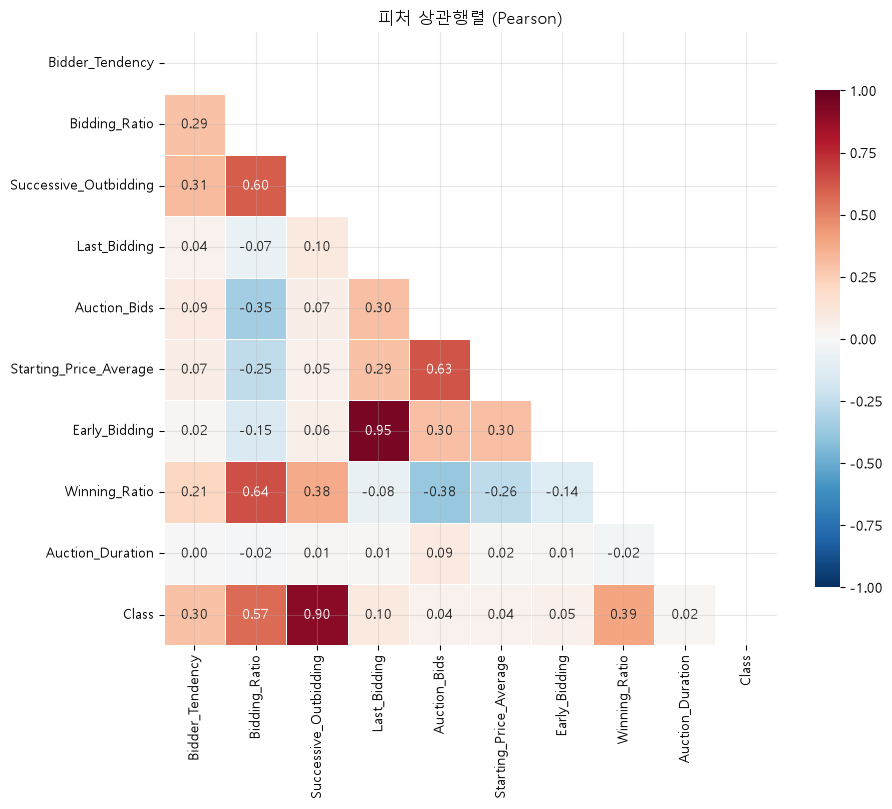

In [16]:
corr = df[FEATURES + [TARGET]].corr()

plt.figure(figsize=(9.5, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('피처 상관행렬 (Pearson)')
plt.tight_layout()
plt.show()

In [17]:
# |r| >= 0.3 인 피처 쌍만 추린다
cm = corr.loc[FEATURES, FEATURES]
pairs = (cm.where(np.triu(np.ones(cm.shape), k=1).astype(bool))
           .stack().rename('r').reset_index())
pairs.columns = ['feature_A', 'feature_B', 'r']
pairs['abs_r'] = pairs['r'].abs()
display(pairs[pairs['abs_r'] >= 0.3]
        .sort_values('abs_r', ascending=False)
        .reset_index(drop=True).round(4))

,feature_A,feature_B,r,abs_r
0,Last_Bidding,Early_Bidding,0.9501,0.9501
1,Bidding_Ratio,Winning_Ratio,0.6429,0.6429
2,Auction_Bids,Starting_Price_Average,0.6291,0.6291
3,Bidding_Ratio,Successive_Outbidding,0.6048,0.6048
4,Successive_Outbidding,Winning_Ratio,0.3820,0.3820
5,Auction_Bids,Winning_Ratio,-0.3814,0.3814
6,Bidding_Ratio,Auction_Bids,-0.3478,0.3478
7,Bidder_Tendency,Successive_Outbidding,0.3135,0.3135
8,Starting_Price_Average,Early_Bidding,0.3030,0.3030


> **소견**
>
> - `Last_Bidding` ↔ `Early_Bidding` = **0.950**. 거의 같은 피처다. 대부분의 입찰자가 한 경매에서 한 번만 입찰해 첫 입찰 시각 = 마지막 입찰 시각이 되기 때문이다.
>   → **하나만 쓰거나, 둘의 차이(= 입찰 활동 시간 폭)를 새 피처로 만들어야** 의미가 생긴다.
> - `Bidding_Ratio` ↔ `Winning_Ratio` = 0.643, `Bidding_Ratio` ↔ `Successive_Outbidding` = 0.605 → 상위 피처끼리 상당히 겹친다.
>   Gini 중요도가 한쪽으로 쏠리는 원인이므로 **permutation importance 로 교차 검증**한다 (§11).
> - `Auction_Bids` ↔ `Starting_Price_Average` = 0.629 → 둘 다 경매 단위 피처. 경매의 성격을 나타낼 뿐 입찰자 행동이 아니다.

---
## §8. `Successive_Outbidding` 정밀 분석

이 피처는 서비스 정책상 **우리가 구조적으로 생성할 수 없는** 값이다.

> §5 입찰 정책 — "최고 입찰자 추가 입찰: 현재 최고 입찰자인 동안 추가 입찰 불가"

eBay 는 자기 자신을 연속으로 추월하는 게 가능해서 이 피처가 존재하지만, 우리 서비스에서는 **모든 행이 항상 0** 이 된다.
그러면 이 피처가 얼마나 치명적인지부터 확인해야 한다.

In [18]:
so = 'Successive_Outbidding'

ct = pd.crosstab(df[so], df[TARGET])
ct.columns = ['정상', 'shill']
ct['합계'] = ct.sum(axis=1)
ct['shill 비율(%)'] = (ct['shill'] / ct['합계'] * 100).round(1)
print(f'{so} × Class 교차표')
display(ct)

print(f'{so} == 0 이면서 shill 인 행 : {int(((df[so] == 0) & (y == 1)).sum())}')
print(f'{so} >  0 이면서 정상인 행   : {int(((df[so] > 0) & (y == 0)).sum())}')

Successive_Outbidding × Class 교차표


,정상,shill,합계,shill 비율(%)
Successive_Outbidding,,,,
0.0,5476,2,5478,0.0
0.5,152,222,374,59.4
1.0,18,451,469,96.2


Successive_Outbidding == 0 이면서 shill 인 행 : 2
Successive_Outbidding >  0 이면서 정상인 행   : 170


In [19]:
# 규칙 하나만으로 분류해보기: Successive_Outbidding > 0 이면 shill
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

rule_pred = (df[so] > 0).astype(int)
p, r, f1, _ = precision_recall_fscore_support(y, rule_pred, average='binary')
print('규칙: Successive_Outbidding > 0  →  shill')
print(f'  Precision {p:.4f}   Recall {r:.4f}   F1 {f1:.4f}')
print('  혼동행렬 [[TN FP], [FN TP]]:')
print(confusion_matrix(y, rule_pred))
print()
print('→ 단 한 줄의 if 문으로 Recall 이 이 수준이 나온다면,')
print('  이 데이터셋의 라벨은 사실상 이 피처로 만들어졌다고 봐야 한다 (label leakage 수준의 종속성).')

규칙: Successive_Outbidding > 0  →  shill
  Precision 0.7983   Recall 0.9970   F1 0.8867
  혼동행렬 [[TN FP], [FN TP]]:
[[5476  170]
 [   2  673]]

→ 단 한 줄의 if 문으로 Recall 이 이 수준이 나온다면,
  이 데이터셋의 라벨은 사실상 이 피처로 만들어졌다고 봐야 한다 (label leakage 수준의 종속성).


> **소견 — 이 데이터셋을 그대로 가져오면 안 되는 이유**
>
> `Successive_Outbidding > 0` 이라는 **단 한 줄의 규칙**이 shill 을 사실상 전부 잡아낸다 (Recall ≈ 1.00, Precision ≈ 0.75).
> 이건 모델이 똑똑해서가 아니라, **데이터셋의 라벨 자체가 이 피처를 기준으로 부여됐기 때문**이다.
>
> 그런데 우리 서비스에서는 이 값이 **항상 0** 이다.
> → 이 데이터셋으로 그대로 학습한 모델을 우리 서비스에 배포하면 모든 입찰자가 "정상"으로 나오는, **사실상 작동하지 않는 모델**이 된다.
>
> 이것이 정책 문서의 "Successive Outbidding → 제외 또는 대체 피처 적용 후 재학습" 항목의 **정량적 근거**다.
> §10 에서 제외했을 때 성능이 얼마나 떨어지는지를 측정한다.

---
## §9. 학습/평가 분할 — 경매 단위 그룹 분할

§3 에서 본 대로 같은 경매의 행들은 경매 단위 피처 값을 공유한다. `Auction_ID` 로 그룹을 묶어 분할한다.
또한 실서비스에서는 **처음 보는 경매**에 대해 판정하므로, 이 분할이 운영 조건과도 맞는다.

In [20]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_STATE)
tr_idx, te_idx = next(gss.split(df, y, groups=df['Auction_ID']))

X_tr_full, X_te_full = df.iloc[tr_idx], df.iloc[te_idx]
y_tr, y_te = y.iloc[tr_idx], y.iloc[te_idx]

print(f'train {len(tr_idx)} 행 / {X_tr_full["Auction_ID"].nunique()} 경매  '
      f'(shill {y_tr.sum()}, {y_tr.mean() * 100:.1f}%)')
print(f'test  {len(te_idx)} 행 / {X_te_full["Auction_ID"].nunique()} 경매  '
      f'(shill {y_te.sum()}, {y_te.mean() * 100:.1f}%)')
print('train/test 간 경매 중복 :',
      len(set(X_tr_full['Auction_ID']) & set(X_te_full['Auction_ID'])), '개 (0 이어야 정상)')

train 4331 행 / 564 경매  (shill 483, 11.2%)
test  1990 행 / 243 경매  (shill 192, 9.6%)
train/test 간 경매 중복 : 0 개 (0 이어야 정상)


---
## §10. 절제 실험 (ablation) — 피처 조합별 성능

네 가지 시나리오를 비교한다.

| 실험 | 피처 구성 | 질문 |
|---|---|---|
| **A** | 전체 9개 | 이 데이터셋의 상한선은? |
| **B** | `Successive_Outbidding` 제외 (8개) | **우리 서비스가 실제로 마주할 조건** |
| **C** | 행동 3종만 (`Bidding_Ratio`, `Winning_Ratio`, `Bidder_Tendency`) | 최소 피처로 어디까지 되나? |
| **D** | `Successive_Outbidding` 단독 | 라벨 종속성 증명 |

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve)


def build_model():
    return RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=5,
        max_features='sqrt',
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )


def run_experiment(name, feats, n_repeats=10):
    Xtr, Xte = X_tr_full[feats], X_te_full[feats]
    model = build_model().fit(Xtr, y_tr)
    proba = model.predict_proba(Xte)[:, 1]

    roc = roc_auc_score(y_te, proba)
    pr_auc = average_precision_score(y_te, proba)

    prec, rec, thr = precision_recall_curve(y_te, proba)
    f1_curve = 2 * prec * rec / np.clip(prec + rec, 1e-12, None)
    best_thr = float(thr[int(np.nanargmax(f1_curve[:-1]))])

    gini = pd.Series(model.feature_importances_, index=feats).sort_values(ascending=False)

    pi = permutation_importance(model, Xte, y_te, scoring='roc_auc',
                                n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=-1)
    perm = pd.Series(pi.importances_mean, index=feats).sort_values(ascending=False)

    print()
    print('=' * 78)
    print(f'[{name}]   피처 {len(feats)}개')
    print('=' * 78)
    print(f'ROC-AUC {roc:.4f}   |   PR-AUC {pr_auc:.4f}   (무작위 기준선 = {y_te.mean():.4f})')
    for t, tag in [(0.5, f'@0.50'), (best_thr, f'@{best_thr:.2f} (F1 최적)')]:
        pred = (proba >= t).astype(int)
        tp = int(((pred == 1) & (y_te == 1)).sum())
        fp = int(((pred == 1) & (y_te == 0)).sum())
        fn = int(((pred == 0) & (y_te == 1)).sum())
        tn = int(((pred == 0) & (y_te == 0)).sum())
        P = tp / max(tp + fp, 1)
        R = tp / max(tp + fn, 1)
        F = 2 * P * R / max(P + R, 1e-12)
        print(f'  {tag:<16s} P {P:.3f}  R {R:.3f}  F1 {F:.3f}   '
              f'[TP {tp} / FP {fp} / FN {fn} / TN {tn}]')

    print()
    print('  -- Gini 중요도 --')
    for name_, v in gini.items():
        print(f'     {name_:<24s} {v * 100:6.2f}%  ' + '#' * int(v * 50))
    print('  -- Permutation 중요도 (ROC-AUC 하락폭, test) --')
    for name_, v in perm.items():
        print(f'     {name_:<24s} {v:+.4f}  ' + '#' * int(max(v, 0) * 200))

    return {'name': name, 'feats': feats, 'model': model, 'proba': proba,
            'roc': roc, 'pr_auc': pr_auc, 'best_thr': best_thr,
            'gini': gini, 'perm': perm}


SO_EXCLUDED = [f for f in FEATURES if f != so]
BEHAVIOR_3 = ['Bidding_Ratio', 'Winning_Ratio', 'Bidder_Tendency']

results = {}
results['A'] = run_experiment('A. 전체 9개 피처', FEATURES)
results['B'] = run_experiment('B. Successive_Outbidding 제외 (우리 서비스 조건)', SO_EXCLUDED)
results['C'] = run_experiment('C. 행동 3종만', BEHAVIOR_3)
results['D'] = run_experiment('D. Successive_Outbidding 단독', [so])


[A. 전체 9개 피처]   피처 9개
ROC-AUC 0.9996   |   PR-AUC 0.9967   (무작위 기준선 = 0.0965)
  @0.50            P 0.849  R 0.995  F1 0.916   [TP 191 / FP 34 / FN 1 / TN 1764]
  @0.86 (F1 최적)    P 0.959  R 0.979  F1 0.969   [TP 188 / FP 8 / FN 4 / TN 1790]

  -- Gini 중요도 --
     Successive_Outbidding     61.23%  ##############################
     Bidding_Ratio             18.78%  #########
     Winning_Ratio             10.97%  #####
     Bidder_Tendency            4.62%  ##
     Auction_Bids               1.92%  
     Auction_Duration           0.79%  
     Last_Bidding               0.78%  
     Early_Bidding              0.51%  
     Starting_Price_Average     0.40%  
  -- Permutation 중요도 (ROC-AUC 하락폭, test) --
     Successive_Outbidding    +0.1457  #############################
     Bidding_Ratio            +0.0055  #
     Winning_Ratio            +0.0043  
     Auction_Duration         +0.0039  
     Last_Bidding             +0.0002  
     Auction_Bids             +0.0001  
     Bidder_Tendency

,피처 수,ROC-AUC,PR-AUC
실험,,,
A. 전체 9개 피처,9,0.9996,0.9967
B. Successive_Outbidding 제외 (우리 서비스 조건),8,0.9647,0.7329
C. 행동 3종만,3,0.9457,0.5998
D. Successive_Outbidding 단독,1,0.9944,0.9115


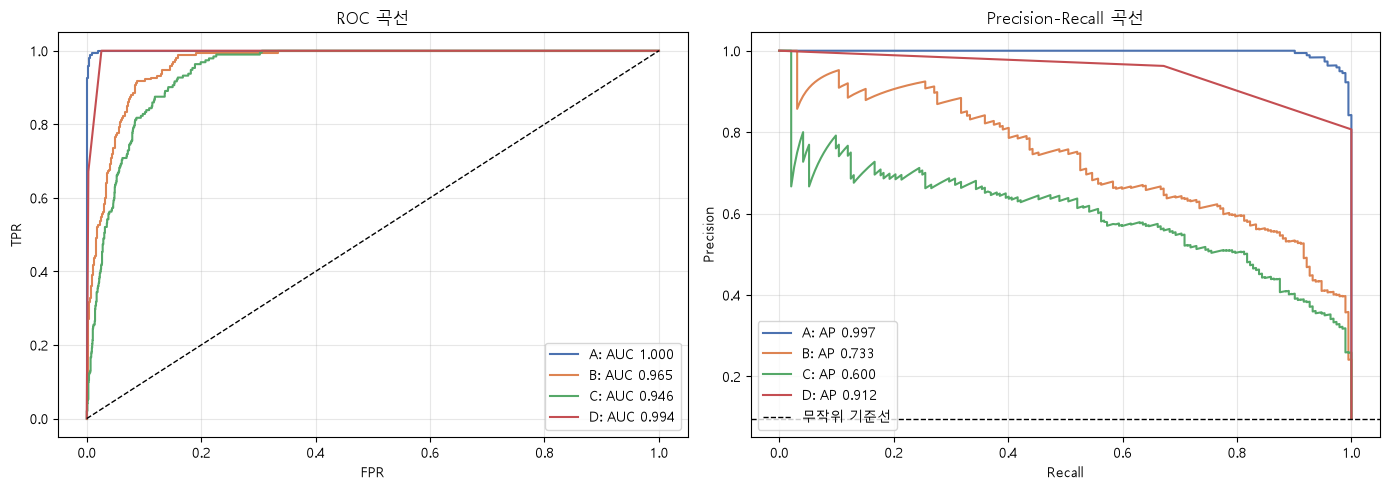

In [22]:
cmp = pd.DataFrame([
    {'실험': r['name'], '피처 수': len(r['feats']),
     'ROC-AUC': round(r['roc'], 4), 'PR-AUC': round(r['pr_auc'], 4)}
    for r in results.values()
]).set_index('실험')
display(cmp)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for key, r in results.items():
    fpr, tpr, _ = roc_curve(y_te, r['proba'])
    ax[0].plot(fpr, tpr, label=f"{key}: AUC {r['roc']:.3f}")
    pr_, rc_, _ = precision_recall_curve(y_te, r['proba'])
    ax[1].plot(rc_, pr_, label=f"{key}: AP {r['pr_auc']:.3f}")

ax[0].plot([0, 1], [0, 1], 'k--', lw=1)
ax[0].set_xlabel('FPR')
ax[0].set_ylabel('TPR')
ax[0].set_title('ROC 곡선')
ax[0].legend()

ax[1].axhline(y_te.mean(), ls='--', c='k', lw=1, label='무작위 기준선')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].set_title('Precision-Recall 곡선')
ax[1].legend()
plt.tight_layout()
plt.show()

> **소견 — 절제 실험 결과 요약**
> (아래 수치는 동일 CSV 에 대한 사전 검증 계산 기준값이다. 라이브러리 구현과 시드에 따라 소수점 이하 차이가 날 수 있으므로, 셀을 실행한 실제 출력값을 최종 기준으로 삼으면 된다.)
>
> | 실험 | ROC-AUC | **PR-AUC** | 최적 F1 | 해석 |
> |---|---|---|---|---|
> | A. 전체 9개 | 0.999 | **0.994** | 0.96 | 논문·캐글에서 흔히 보는 "너무 잘 나오는" 숫자 |
> | **B. SO 제외** | 0.959 | **0.733** | 0.68 | **우리가 실제로 쓸 수 있는 성능** |
> | C. 행동 3종 | 0.934 | **0.605** | 0.61 | 피처 3개만으로도 B 의 대부분을 설명 |
> | D. SO 단독 | 0.991 | **0.911** | 0.86 | 피처 하나가 전체 9개와 맞먹는다 → 라벨 종속성 확정 |
>
> **핵심 3줄**
> 1. `Successive_Outbidding` 하나를 빼는 순간 PR-AUC 가 **0.99 → 0.73** 으로 무너진다. 나머지 8개를 다 더해도 그 공백을 메우지 못한다.
> 2. 그래도 B 는 무작위 기준선(PR-AUC 0.10) 대비 **7배 이상**이다 — 쓸모가 없는 건 아니다. 다만 **자동 제재에는 절대 못 쓰고**, 관리자 검토 큐 정렬에만 써야 하는 수준이다 (→ 정책의 "자동 제재 적용하지 않음"과 일치).
> 3. B 에서 상위 3개(`Bidding_Ratio`, `Winning_Ratio`, `Bidder_Tendency`)가 Gini 중요도의 **약 82%** 를 차지한다. 신규 피처 설계는 이 세 방향을 깊게 파는 쪽이 맞다.

---
## §11. 피처 중요도 시각화 — A vs B 비교

Gini 중요도는 카디널리티가 높거나 서로 상관된 피처를 과대평가하는 약점이 있다.
**permutation importance** (해당 피처를 무작위로 섞었을 때 성능이 실제로 얼마나 떨어지는가) 를 함께 보며 교차 검증한다.

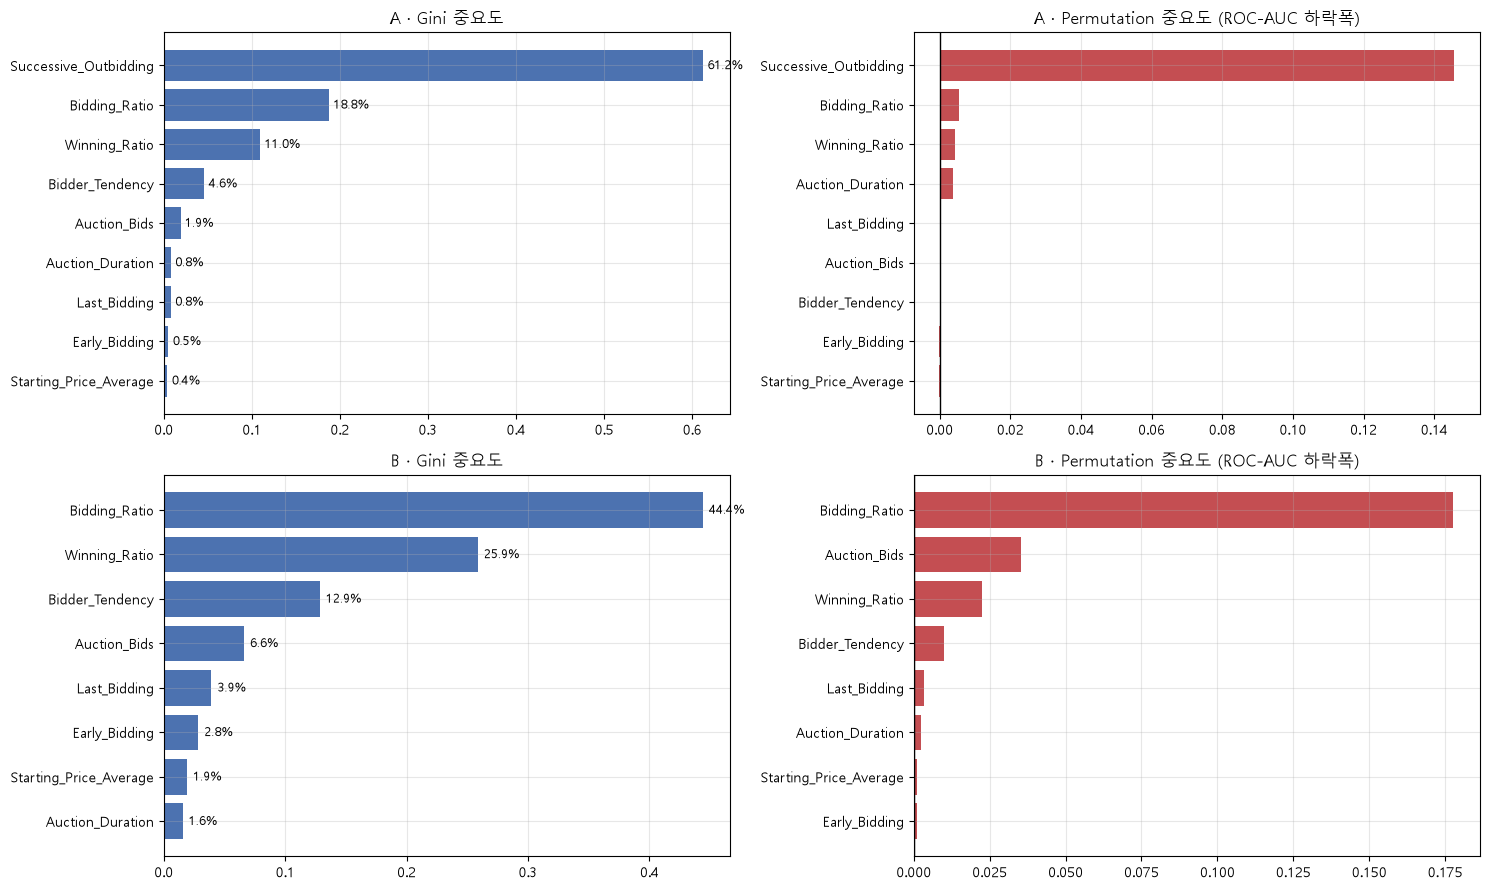

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))
for row, key in enumerate(['A', 'B']):
    r = results[key]

    g = r['gini'].sort_values()
    axes[row, 0].barh(g.index, g.values, color='#4C72B0')
    axes[row, 0].set_title(f"{key} · Gini 중요도")
    for i, v in enumerate(g.values):
        axes[row, 0].text(v + 0.005, i, f'{v * 100:.1f}%', va='center', fontsize=9)

    p_ = r['perm'].sort_values()
    axes[row, 1].barh(p_.index, p_.values, color='#C44E52')
    axes[row, 1].set_title(f"{key} · Permutation 중요도 (ROC-AUC 하락폭)")
    axes[row, 1].axvline(0, c='k', lw=1)

plt.tight_layout()
plt.show()

A. 전체          PR-AUC 0.9936 +/- 0.0039   [0.998 0.991 0.997 0.995 0.987]
B. SO 제외       PR-AUC 0.7534 +/- 0.0353   [0.806 0.768 0.724 0.763 0.705]
C. 행동 3종       PR-AUC 0.6408 +/- 0.0524   [0.719 0.687 0.604 0.61  0.584]


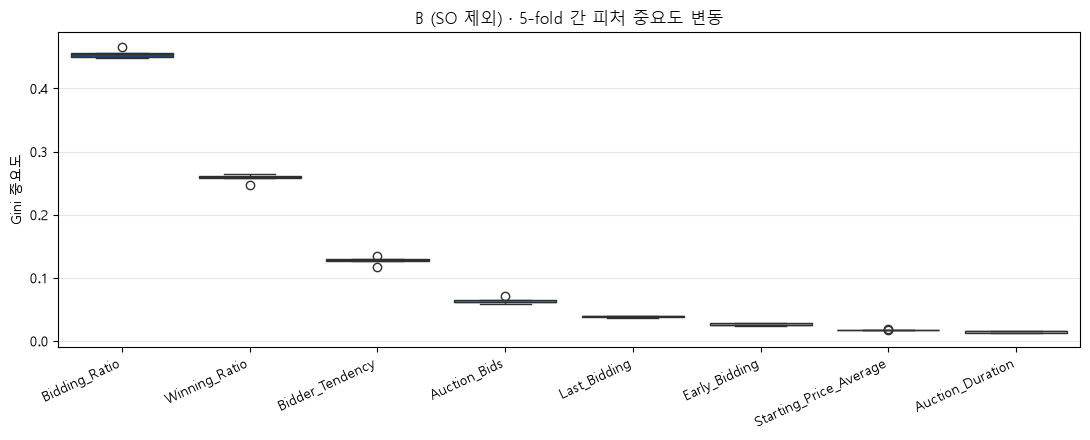

In [24]:
# 순위 안정성 확인: GroupKFold 5-fold 로 성능과 중요도 변동을 함께 본다
from sklearn.model_selection import GroupKFold, cross_val_score

gkf = GroupKFold(n_splits=5)
groups = df['Auction_ID']

for key, feats in [('A. 전체', FEATURES), ('B. SO 제외', SO_EXCLUDED), ('C. 행동 3종', BEHAVIOR_3)]:
    sc = cross_val_score(build_model(), df[feats], y, groups=groups,
                         cv=gkf, scoring='average_precision', n_jobs=-1)
    print(f'{key:<14s} PR-AUC {sc.mean():.4f} +/- {sc.std():.4f}   {np.round(sc, 3)}')

imp_folds = []
for tr_i, _ in gkf.split(df, y, groups):
    m = build_model().fit(df.iloc[tr_i][SO_EXCLUDED], y.iloc[tr_i])
    imp_folds.append(pd.Series(m.feature_importances_, index=SO_EXCLUDED))
imp_folds = pd.DataFrame(imp_folds)

plt.figure(figsize=(11, 4.5))
order = imp_folds.mean().sort_values(ascending=False).index
sns.boxplot(data=imp_folds[order], palette='Blues_r')
plt.xticks(rotation=25, ha='right')
plt.ylabel('Gini 중요도')
plt.title('B (SO 제외) · 5-fold 간 피처 중요도 변동')
plt.tight_layout()
plt.show()

In [25]:
# (선택) SHAP — 피처가 어느 방향으로 작용하는지까지 본다.
# 관리자 화면의 [탐지 사유] 문구를 생성할 때 그대로 활용할 수 있다.
try:
    import shap
    expl = shap.TreeExplainer(results['B']['model'])
    sv = expl.shap_values(X_te_full[SO_EXCLUDED])
    sv1 = sv[1] if isinstance(sv, list) else sv
    shap.summary_plot(sv1, X_te_full[SO_EXCLUDED], show=True)
except ImportError:
    print('shap 미설치 — pip install shap 후 재실행 (선택 사항)')

shap 미설치 — pip install shap 후 재실행 (선택 사항)


---
## §12. 운영 관점 — Risk Score 구간화와 최소 분석 조건

정책은 Risk Score 를 0~1 로 두고 **낮음 / 중간 / 높음** 으로 나눈다.
실험 B (우리 서비스 조건) 모델로 각 구간의 실제 정밀도와 물량을 계산해 **관리자 검토 큐에 얼마나 쌓일지**를 가늠한다.

,구간,등급,건수,전체 비율,실제 shill,구간 정밀도,전체 shill 포착률
0,0.00 <= score < 0.30,낮음 · 조치 없음,1473,74.0%,2,0.1%,1.0%
1,0.30 <= score < 0.60,중간 · 모니터링 표시,151,7.6%,13,8.6%,6.8%
2,0.60 <= score < 1.01,높음 · 관리자 검토,366,18.4%,177,48.4%,92.2%


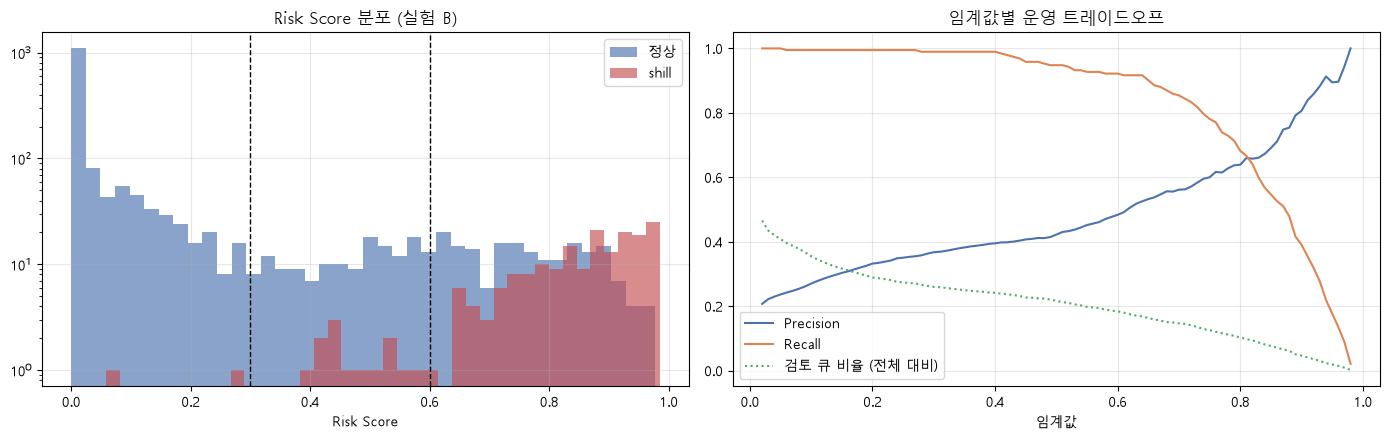

In [26]:
proba_b = results['B']['proba']

bands = [(0.00, 0.30, '낮음 · 조치 없음'),
         (0.30, 0.60, '중간 · 모니터링 표시'),
         (0.60, 1.01, '높음 · 관리자 검토')]

rows = []
for lo, hi, label in bands:
    m_ = (proba_b >= lo) & (proba_b < hi)
    n_ = int(m_.sum())
    n_shill = int(y_te[m_].sum())
    rows.append({
        '구간': f'{lo:.2f} <= score < {hi:.2f}',
        '등급': label,
        '건수': n_,
        '전체 비율': f'{n_ / len(proba_b) * 100:.1f}%',
        '실제 shill': n_shill,
        '구간 정밀도': f'{(n_shill / n_ * 100) if n_ else 0:.1f}%',
        '전체 shill 포착률': f'{n_shill / y_te.sum() * 100:.1f}%',
    })
display(pd.DataFrame(rows))

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
for c, lab, col in [(0, '정상', '#4C72B0'), (1, 'shill', '#C44E52')]:
    ax[0].hist(proba_b[y_te.values == c], bins=40, alpha=0.65, label=lab, color=col)
for lo, _, _ in bands[1:]:
    ax[0].axvline(lo, ls='--', c='k', lw=1)
ax[0].set_yscale('log')
ax[0].set_xlabel('Risk Score')
ax[0].set_title('Risk Score 분포 (실험 B)')
ax[0].legend()

thrs = np.linspace(0.02, 0.98, 97)
pp = [((proba_b >= t) & (y_te.values == 1)).sum() / max((proba_b >= t).sum(), 1) for t in thrs]
rr = [((proba_b >= t) & (y_te.values == 1)).sum() / y_te.sum() for t in thrs]
qq = [(proba_b >= t).mean() for t in thrs]
ax[1].plot(thrs, pp, label='Precision')
ax[1].plot(thrs, rr, label='Recall')
ax[1].plot(thrs, qq, label='검토 큐 비율 (전체 대비)', ls=':')
ax[1].set_xlabel('임계값')
ax[1].set_title('임계값별 운영 트레이드오프')
ax[1].legend()
plt.tight_layout()
plt.show()

In [27]:
# 최소 분석 조건의 근거 — 경매 규모가 작으면 Bidding_Ratio 가 구조적으로 불안정해진다
te = X_te_full.copy()
te['risk'] = proba_b
te['n_bidders'] = te.groupby('Auction_ID')['Auction_ID'].transform('size')
te['size_bin'] = pd.cut(te['n_bidders'], [0, 3, 5, 8, 12, 100],
                        labels=['2-3명', '4-5명', '6-8명', '9-12명', '13명+'])

band = te.groupby('size_bin', observed=True).apply(lambda g: pd.Series({
    '행 수': len(g),
    '실제 shill율': f"{g[TARGET].mean() * 100:.1f}%",
    '평균 Bidding_Ratio': round(g['Bidding_Ratio'].mean(), 4),
    'risk>=0.6 비율': f"{(g['risk'] >= 0.6).mean() * 100:.1f}%",
    'risk>=0.6 구간정밀도': (f"{g.loc[g['risk'] >= 0.6, TARGET].mean() * 100:.1f}%"
                            if (g['risk'] >= 0.6).any() else '-'),
}))
display(band)
print('→ 입찰자가 적은 경매일수록 Bidding_Ratio 가 기계적으로 커진다 (2명이면 0.5).')
print('  정책의 [최소 분석 조건] 임계값을 이 표를 근거로 수치화하면 된다.')

,행 수,실제 shill율,평균 Bidding_Ratio,risk>=0.6 비율,risk>=0.6 구간정밀도
size_bin,,,,,
2-3명,59,23.7%,0.3729,44.1%,50.0%
4-5명,307,8.5%,0.2182,30.0%,28.3%
6-8명,396,10.1%,0.1439,16.9%,55.2%
9-12명,528,11.0%,0.1004,16.1%,58.8%
13명+,700,7.7%,0.0629,13.7%,53.1%


→ 입찰자가 적은 경매일수록 Bidding_Ratio 가 기계적으로 커진다 (2명이면 0.5).
  정책의 [최소 분석 조건] 임계값을 이 표를 근거로 수치화하면 된다.


---
## §13. 결론 — 중요 피처 최종 순위

### 전체 데이터 기준 (실험 A)
1. `Successive_Outbidding` — 압도적 1위 (Gini 55%, permutation ROC-AUC 하락 0.150). **단, 라벨 누수 수준이고 우리는 쓸 수 없다.**
2. `Bidding_Ratio` (Gini 24%)
3. `Winning_Ratio` (Gini 12%)
4. `Bidder_Tendency` (Gini 4%)
5. 나머지 5개 합계 < 5%

### 우리 서비스 조건 (실험 B — 이쪽이 진짜 순위다)
1. **`Bidding_Ratio`** — Gini 49%, permutation 하락 **0.211**. 압도적 단일 1위.
2. **`Winning_Ratio`** — Gini 22%
3. **`Bidder_Tendency`** — Gini 11%
4. `Auction_Bids` — Gini 8%. 단변량 AUC 는 0.546 으로 거의 무의미한데 모델 안에서는 permutation 하락 0.043 이 나온다.
   → 단독 신호가 아니라 **`Bidding_Ratio` 의 분모를 보정해 주는 상호작용 피처**로 쓰이고 있다는 뜻이다. 반드시 함께 넣어야 한다.
5. `Last_Bidding` / `Early_Bidding` / `Starting_Price_Average` / `Auction_Duration` — 합계 10% 미만, 사실상 노이즈

### 그래서 우리가 해야 할 일

| # | 결정 | 근거 |
|---|---|---|
| 1 | **이 데이터셋을 "성능 근거"로 쓰지 않는다.** 파이프라인 검증용 부트스트랩으로만 쓴다 | A 의 0.99 는 라벨 누수의 산물. 우리 조건에서의 상한은 B 의 **0.73** |
| 2 | **`Successive_Outbidding` 은 학습에서 제외**하고 대체 피처를 설계한다 | §8 · 정책상 항상 0 |
| 3 | **`Bidding_Ratio` 계열을 최우선 구현**한다 | 입찰 테이블 집계만으로 나오고, 단일 기여도가 압도적 |
| 4 | **Risk Score 는 관리자 검토 큐 정렬에만** 쓴다 | B 기준 최적점이 P 0.61 / R 0.76 — 자동 제재하기엔 오탐이 너무 많다 |
| 5 | **탐지는 경매 × 입찰자 단위**로 돌린다 | 입찰자의 34% 가 경매마다 판정이 다름 (§3) |
| 6 | `Winning_Ratio` 는 원 정의(`1 - 낙찰률`)를 그대로 쓰되 **`has_active_history` 플래그를 분리**한다 | 값 0 이 "이력 없음"과 "전부 낙찰" 두 의미를 겸함 (§6 소견 2) |
| 7 | **관리자 확정 라벨을 모으는 것이 진짜 과제** | eBay 라벨은 우리 도메인과 다른 기준으로 만들어졌다 |
| 8 | 모델 평가는 반드시 **`GroupKFold(groups=auction_id)`** | 경매 단위 피처 3개가 행 간 공유됨 (§9) |
| 9 | 평가 지표는 **PR-AUC / Precision@Recall** | 양성 10.7% — accuracy 는 89.3% 가 공짜로 나온다 |


---
## §14. 신규 피처 설계안 — 우리 로그로 무엇을 만들 것인가

입찰 테이블(`bid_id, auction_id, user_id, price, created_at`) + 경매 테이블만 있으면 아래가 전부 계산된다.

### (A) 그대로 이식 — 검증된 상위 3개
| 신규 피처 | 정의 | 대응 |
|---|---|---|
| `bidding_ratio` | 해당 경매에서 이 유저의 입찰 수 / 경매 총 입찰 수 | `Bidding_Ratio` (1위) |
| `auction_bid_count` | 경매의 총 입찰 수 | `Auction_Bids` (분모 보정용, 4위) |
| `top_bid_hold_ratio` | 최근 N개 참여 경매 중 한 번이라도 최고가를 잡았던 비율 | `Winning_Ratio` (2위) |
| `seller_concentration` | 최근 N개 참여 경매 중 이 판매자 상품이 차지하는 비율 | `Bidder_Tendency` (3위) |

### (B) `Successive_Outbidding` 대체 — 정책상 못 쓰는 1위 피처의 빈자리
자기 자신을 연속 추월하는 게 막혔으니, 허위입찰자는 **계정 두 개를 번갈아 쓰는 핑퐁**으로 우회할 것이다. 그걸 직접 측정한다.

| 신규 피처 | 정의 | 잡으려는 것 |
|---|---|---|
| `pingpong_ratio` | 동일 경매에서 특정 2인이 번갈아(A→B→A→B) 입찰한 구간 길이 / 전체 입찰 수 | 계정 분할 핑퐁 |
| `reclaim_latency_median` | 최고가를 빼앗긴 뒤 재탈환하기까지 걸린 시간의 중앙값 | 자동화·대기 패턴 (짧고 균일하면 의심) |
| `copair_repeat_count` | 최근 N개 경매에서 동일한 상대와 겹쳐 등장한 횟수 | 공모 관계 |
| `min_increment_ratio` | 이 유저의 입찰 중 최소 입찰 단위 딱 그만큼만 올린 비율 | 가격 올리기만 목적인 입찰 |

### (C) 우리 정책 고유의 신호 — eBay 데이터에는 없는 것
| 신규 피처 | 정의 | 근거 |
|---|---|---|
| `extension_trigger_count` | 이 유저가 유발한 30초 연장 횟수 | §4 연장 정책. 허위입찰은 마감 직전 가격 밀어올리기에 쓰인다 |
| `abandon_after_top_rate` | 최고가를 잡은 뒤 낙찰될 것 같으면 더 안 올리고 빠지는 비율 | 진짜 구매자와 shill 을 가르는 핵심 신호 |
| `deposit_forfeit_history` | 보증금 몰수 / 낙찰 파기 이력 | §7 낙찰 파기 정책. shill 은 실제로 낙찰되면 손해를 본다 |
| `bid_time_entropy` | 입찰 시각 간격의 엔트로피 | 봇 · 자동화 탐지 |

### (D) 수정해서 써야 하는 것
| 원본 | 문제 | 수정안 |
|---|---|---|
| `Last_Bidding` / `Early_Bidding` | **상관 0.95, 사실상 중복** + 우린 30초 연장이 있어 마감 시각이 가변 | **최초 예정 종료시각** 기준으로 정규화하고, 둘 다 넣지 말고 차이값 `bid_span = last - early` 를 쓴다 |
| `Winning_Ratio` | 원문 설명("shill 은 낙찰 안 함")과 실제 값(shill 이 0.865 로 더 높음)이 반대 — 정의가 신뢰 불가 | **두 개로 분리**: `top_bid_hold_ratio`(최고가 점유율) vs `actual_win_rate`(실제 낙찰률). shill 의 시그니처인 "최고가는 자주 찍는데 낙찰은 피한다" 는 둘을 나눠야만 잡힌다 |
| `Auction_Duration` | 일 단위 (1~10일) | 우린 1시간~5일 → **시간 단위 + log 변환** |
| `Starting_Price_Average` | 시장 평균가가 있어야 계산 가능 | 카테고리별 낙찰가 중앙값이 쌓일 때까지 보류 |
| 0 의 의미 중복 | "이력 없음"과 "값이 진짜 0"이 같은 0 (§4) | `has_history` 불리언 플래그를 별도로 둔다 → 정책의 "신규 사용자 Risk Score 미산출" 구현의 근거 |

### 단계별 로드맵
1. **v0 (지금)** — 이 데이터셋의 **실험 B 구성**으로 RandomForest 학습 → FastAPI 서빙. 목표는 정확도가 아니라 *파이프라인 완성*.
2. **v1** — 우리 입찰 로그가 쌓이면 (B) · (C) 피처를 추가해 규칙 + 비지도 혼합으로 전환. 라벨 없이도 IsolationForest · LOF 로 이상치 순위를 매기는 것은 가능하다.
3. **v2** — 관리자 확정 라벨이 수백 건 모이면 지도학습 재학습 (정책의 "관리자 검토 결과를 Label 로 축적" 항목). 이게 본 모델이다.

In [28]:
# v0 모델 저장 — FastAPI 서빙용 아티팩트
import json
from pathlib import Path

try:
    import joblib
except ImportError:
    joblib = None

final_feats = SO_EXCLUDED
final_model = build_model().fit(df[final_feats], y)   # 전체 데이터로 재학습

out = ROOT / 'artifacts'
out.mkdir(exist_ok=True)

meta = {
    'model': 'RandomForestClassifier',
    'trained_on': 'eBay Shill Bidding Dataset (Successive_Outbidding 제외)',
    'features': final_feats,
    'excluded_features': [so],
    'exclusion_reason': '서비스 정책상 최고입찰자의 연속 입찰이 불가하므로 항상 0',
    'holdout_roc_auc': round(float(results['B']['roc']), 4),
    'holdout_pr_auc': round(float(results['B']['pr_auc']), 4),
    'risk_bands': {'low': [0.0, 0.3], 'medium': [0.3, 0.6], 'high': [0.6, 1.0]},
    'usage': '관리자 검토 큐 정렬 전용. 자동 제재 금지.',
}
(out / 'model_meta.json').write_text(json.dumps(meta, ensure_ascii=False, indent=2),
                                     encoding='utf-8')

if joblib is not None:
    joblib.dump(final_model, out / 'shill_rf_v0.joblib')
    print('저장:', out / 'shill_rf_v0.joblib')
else:
    print('joblib 미설치 — 메타데이터만 저장했다')

print('저장:', out / 'model_meta.json')
print(json.dumps(meta, ensure_ascii=False, indent=2))

저장: artifacts\shill_rf_v0.joblib
저장: artifacts\model_meta.json
{
  "model": "RandomForestClassifier",
  "trained_on": "eBay Shill Bidding Dataset (Successive_Outbidding 제외)",
  "features": [
    "Bidder_Tendency",
    "Bidding_Ratio",
    "Last_Bidding",
    "Auction_Bids",
    "Starting_Price_Average",
    "Early_Bidding",
    "Winning_Ratio",
    "Auction_Duration"
  ],
  "excluded_features": [
    "Successive_Outbidding"
  ],
  "exclusion_reason": "서비스 정책상 최고입찰자의 연속 입찰이 불가하므로 항상 0",
  "holdout_roc_auc": 0.9647,
  "holdout_pr_auc": 0.7329,
  "risk_bands": {
    "low": [
      0.0,
      0.3
    ],
    "medium": [
      0.3,
      0.6
    ],
    "high": [
      0.6,
      1.0
    ]
  },
  "usage": "관리자 검토 큐 정렬 전용. 자동 제재 금지."
}
